Running KNN using k = 9


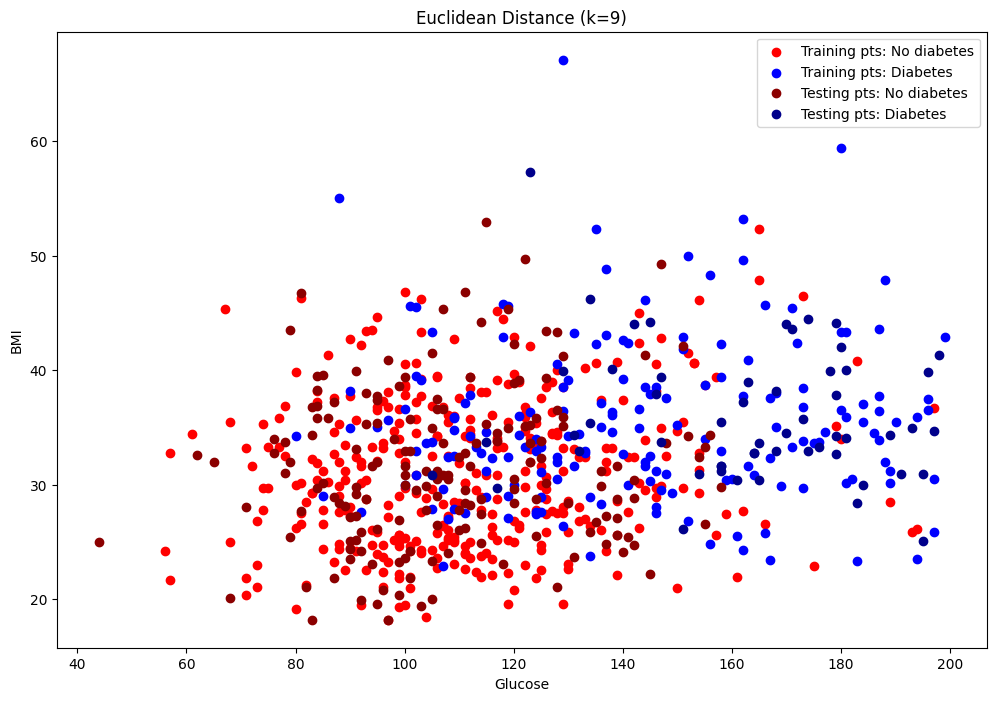

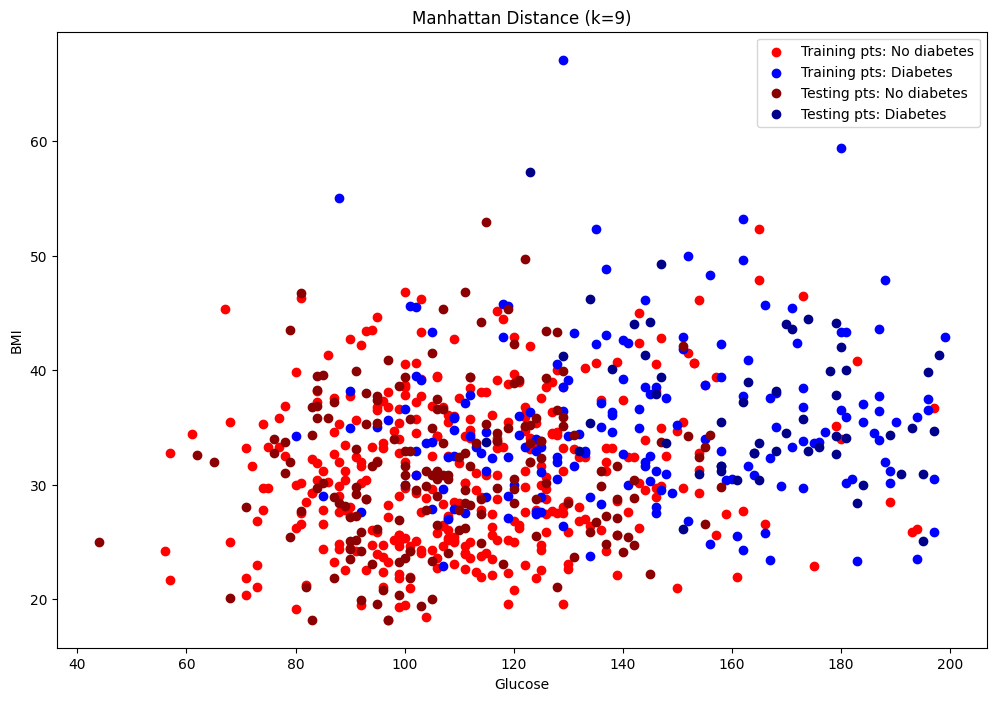

In [7]:
import math, random
import matplotlib.pyplot as plt

def euclidean_distance(x1, x2):
    distance = 0
    for i in range(len(x1)):
        distance += (x1[i] - x2[i])**2
    return math.sqrt(distance)

def manhattan_distance(x1, x2):
    distance = 0
    for i in range(len(x1)):
        distance += abs(x1[i] - x2[i])
    return distance

def knn_classifier(X_train, y_train, x_test, k, metric):
    distance =[]

    #1. Computing the distance from test point to all training points
    # O(n*d)
    for i in range(len(X_train)):
        if metric == "euclidean":
            dist = euclidean_distance(X_train[i], x_test)
        else:
            dist = manhattan_distance(X_train[i], x_test)
       
        distance.append((dist, y_train[i]))

    #2. Sort by distance
    #O(nlg(n))
    distance.sort(key = lambda x: x[0])

    #3. select k nearest neighbors
    k_neighbors = distance[:k]

    #4. majority vote
    class_vote = {}
    for _, label in k_neighbors:
        if label in class_vote:
            class_vote[label]+=1
        else:
            class_vote[label] = 1

    #5. return max class
    return max(class_vote, key = class_vote.get)

def scatter_plot(x_train, y_train, x_test, prediction, title):
    plt.figure(figsize=(12, 8))
   
    train_x0 = [x_train[i][0] for i in range(len(x_train)) if y_train[i] == 0]
    train_y0 = [x_train[i][1] for i in range(len(x_train)) if y_train[i] == 0]
    train_x1 = [x_train[i][0] for i in range(len(x_train)) if y_train[i] == 1]
    train_y1 = [x_train[i][1] for i in range(len(x_train)) if y_train[i] == 1]

    test_x0 = [x_test[i][0] for i in range(len(x_test)) if prediction[i] == 0]
    test_y0 = [x_test[i][1] for i in range(len(x_test)) if prediction[i] == 0]
    test_x1 = [x_test[i][0] for i in range(len(x_test)) if prediction[i] == 1]
    test_y1 = [x_test[i][1] for i in range(len(x_test)) if prediction[i] == 1]


    plt.scatter(train_x0, train_y0, c='red', label = 'Training pts: No diabetes')
    plt.scatter(train_x1, train_y1, c='blue', label = 'Training pts: Diabetes')
    plt.scatter(test_x0, test_y0, c='darkred', label = 'Testing pts: No diabetes')
    plt.scatter(test_x1, test_y1, c='darkblue', label = 'Testing pts: Diabetes')
    plt.title(title)
    plt.xlabel('Glucose')
    plt.ylabel('BMI')
    plt.legend()    
    plt.show()

x = []
y = []

with open("diabetes.csv", 'r') as file:
    lines = file.readlines()[1:]

    for line in lines:
        res = line.strip().split(',')
        
        glucose = float(res[1])
        bmi = float(res[5])
        outcome = int(res[8])
        if glucose > 0 and bmi > 0:
            x.append([glucose, bmi])
            y.append(outcome)

combined = list(zip(x, y))
random.seed(42)
random.shuffle(combined)

x_shuffled, y_shuffled = zip(*combined)
x = list(x_shuffled)
y = list(y_shuffled)

ratio = int(0.7 * len(x))

x_train = x[:ratio]
y_train = y[:ratio]

x_test = x[ratio:]
y_test = y[ratio:]

while True:
    k = input("Enter the value for k (click enter for default value) (q to quit): ")
    if k.lower() == 'q':
        break
    k = int(k) if k else int(math.sqrt(len(x_train)))
    if k % 2 == 0:
        k += 1

    print(f'Running KNN using k = {k}')

    euclidean_predictions = [knn_classifier(x_train, y_train, x_test[i], k, "euclidean") for i in range(len(x_test))]
    manhattan_predictions = [knn_classifier(x_train, y_train, x_test[i], k, "manhattan") for i in range(len(x_test))]
  
    scatter_plot(x_train, y_train, x_test, euclidean_predictions, f'Euclidean Distance (k={k})')
    scatter_plot(x_train, y_train, x_test, manhattan_predictions, f'Manhattan Distance (k={k})')